>Lisbeth Martinez

>Project Title: Identifying Streaming Behavior Across Attributes of Region and Genre

>Description: Understanding patterns in music streaming plat- forms allows labels and artists to visualize how their music is most listened to. Clustering streams by genre and sorting by region enables companies to establish a strategic domain impact. 

#Contents:
1. [Data loading and Overview](#Data-Loading-and-Overview)
2. [Exploratory Data Analysis with Visualizations](#Exploratory-Data-Analysis-with-Visualizations)
3. [Data Transformation and Applying the Mining Technique](#Data-Transformation-and-Applying-the-Mining-Technique)
4. [Preliminary Findings with Interpretation](#Preliminary-Findings-with-Interpretation)

# Data Loading and Overview

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from mlxtend.frequent_patterns import apriori, association_rules

sns.set(style="whitegrid")

>The section below is an overview of the 5000 rows and 12 columns, including: the head displaying the first five rows, information about the data type, and a summary of statistics. Preprocessing checks for missing values, prints them, and also checks for duplicate rows.

Dataset Shape: (5000, 12)


,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%)
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User_ID                                   5000 non-null   str    
 1   Age                                       5000 non-null   int64  
 2   Country                                   5000 non-null   str    
 3   Streaming Platform                        5000 non-null   str    
 4   Top Genre                                 5000 non-null   str    
 5   Minutes Streamed Per Day                  5000 non-null   int64  
 6   Number of Songs Liked                     5000 non-null   int64  
 7   Most Played Artist                        5000 non-null   str    
 8   Subscription Type                         5000 non-null   str    
 9   Listening Time (Morning/Afternoon/Night)  5000 non-null   str    
 10  Discover Weekly Engagement (%)            5000 

,Age,Minutes Streamed Per Day,Number of Songs Liked,Discover Weekly Engagement (%),Repeat Song Rate (%)
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,36.664000,309.237200,253.51720,50.296464,42.391060
std,13.763844,172.029822,146.36928,23.171936,21.444121
min,13.000000,10.000000,1.00000,10.020000,5.000000
25%,25.000000,161.000000,126.00000,30.147500,24.195000
50%,37.000000,316.000000,254.00000,50.420000,41.960000
75%,49.000000,457.250000,382.00000,70.337500,60.740000
max,60.000000,600.000000,500.00000,89.990000,79.990000


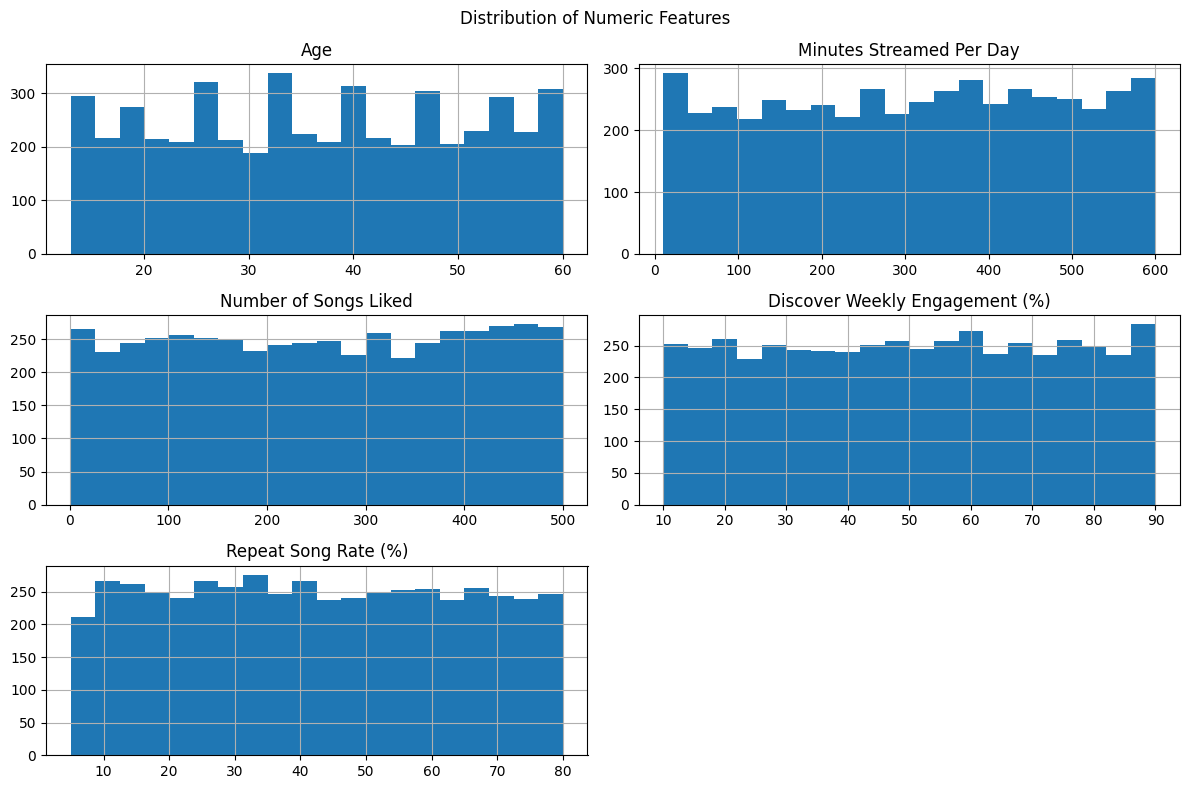

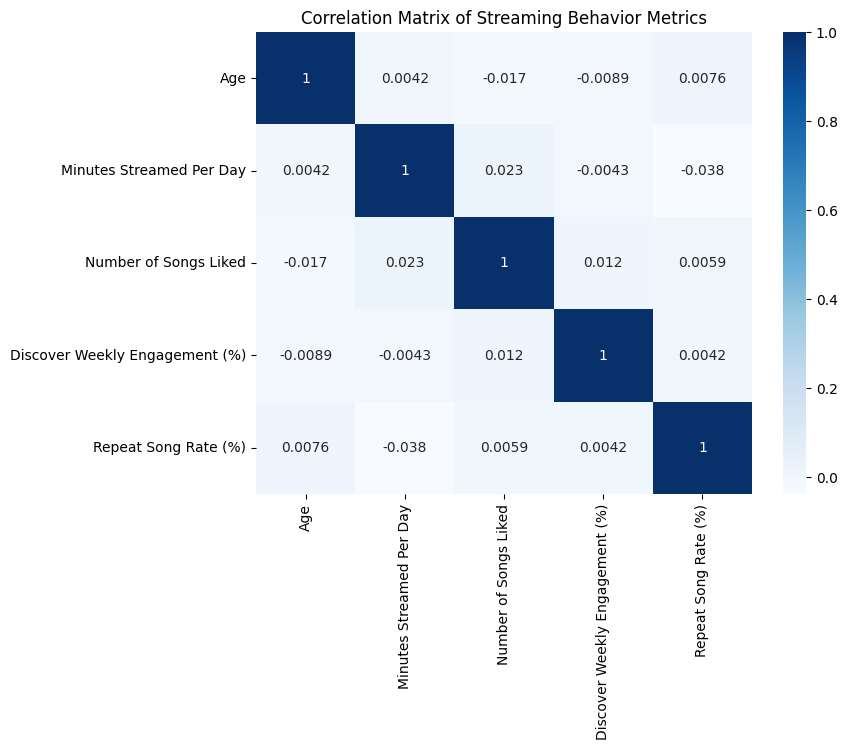


Missing values per column:
User_ID                                     0
Age                                         0
Country                                     0
Streaming Platform                          0
Top Genre                                   0
Minutes Streamed Per Day                    0
Number of Songs Liked                       0
Most Played Artist                          0
Subscription Type                           0
Listening Time (Morning/Afternoon/Night)    0
Discover Weekly Engagement (%)              0
Repeat Song Rate (%)                        0
dtype: int64

Number of duplicate rows: 0


In [12]:
df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

print(f"Dataset Shape: {df.shape}")
#First five rows
display(df.head())

#Type of data
df.info()

#Summary statistics
display(df.describe())
numeric_cols = [
    "Age",
    "Minutes Streamed Per Day",
    "Number of Songs Liked",
    "Discover Weekly Engagement (%)",
    "Repeat Song Rate (%)"
]

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix of Streaming Behavior Metrics")
plt.show()

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Exploratory Data Analysis with Visualizations

>Shows the most frequent data from each column to understand any skews; pre-processing excludes USER ID

In [26]:
df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

most_frequent = df.drop(columns=['User_ID']).mode().iloc[0]
print(most_frequent)

Age                                                 32.0
Country                                        Australia
Streaming Platform                          Amazon Music
Top Genre                                           Jazz
Minutes Streamed Per Day                           152.0
Number of Songs Liked                              320.0
Most Played Artist                             Bad Bunny
Subscription Type                                Premium
Listening Time (Morning/Afternoon/Night)           Night
Discover Weekly Engagement (%)                     76.66
Repeat Song Rate (%)                               16.59
Name: 0, dtype: object


>Genre Popularity by Country shows specific numerics that the bar chart would not for a more direct visualization of how many users have been recording listening to each genre.
>Looking through a category, such as Classical, it is easy to see Brazil and Canada are outliers, with 37 listeners while the other nations hold 45-55.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")
genre_country_df = df[["Country", "Top Genre"]]
genre_counts = genre_country_df.groupby(["Country", "Top Genre"]).size().reset_index(name="Count")
genre_pivot = genre_counts.pivot(index="Country", columns="Top Genre", values="Count").fillna(0)

genre_pivot



Top Genre,Classical,Country,EDM,Hip-Hop,Jazz,Metal,Pop,R&B,Reggae,Rock
Country,,,,,,,,,,
Australia,47,49,53,55,60,43,61,48,55,55
Brazil,59,53,48,39,45,44,56,57,46,61
Canada,37,51,59,51,57,38,56,54,55,49
France,42,47,50,52,59,51,35,51,55,51
Germany,45,45,71,44,44,56,37,50,37,42
India,55,49,42,54,52,45,40,45,62,46
Japan,45,55,48,48,57,51,55,41,49,42
South Korea,48,47,56,61,51,52,34,52,51,64
UK,49,42,42,47,56,58,45,59,63,55


>This boxplot is based off of the previous table as a way to identify significant outliers. For example, seeing a dot at 59, I can then cross-reference the table to identify which country holds that outlier.

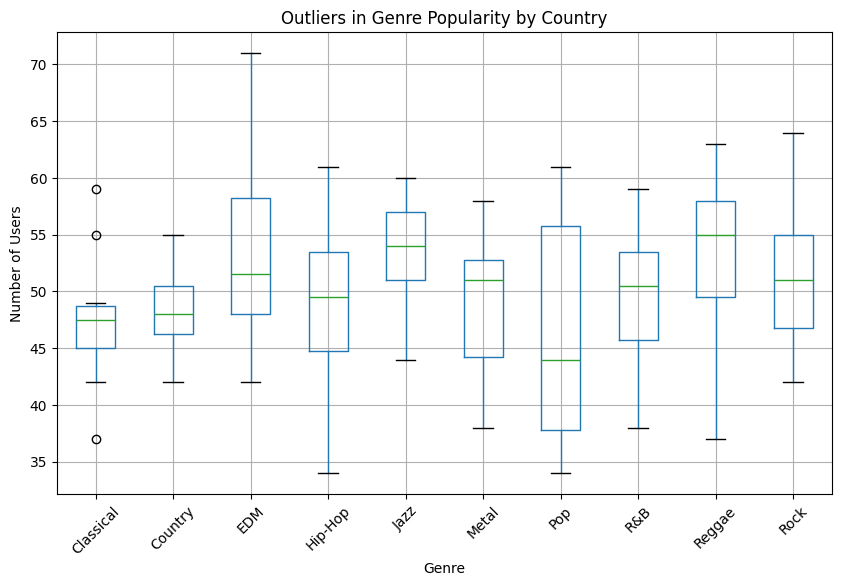

Top Genre  Classical  Country  EDM  Hip-Hop  Jazz  Metal  Pop  R&B  Reggae  \
Country                                                                      
Brazil          59.0      NaN  NaN      NaN   NaN    NaN  NaN  NaN     NaN   
Canada          37.0      NaN  NaN      NaN   NaN    NaN  NaN  NaN     NaN   
India           55.0      NaN  NaN      NaN   NaN    NaN  NaN  NaN     NaN   

Top Genre  Rock  
Country          
Brazil      NaN  
Canada      NaN  
India       NaN  


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")
plt.figure(figsize=(10,6))
genre_pivot.boxplot()

plt.title("Outliers in Genre Popularity by Country")
plt.xlabel("Genre")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)

plt.show()
Q1 = genre_pivot.quantile(0.25)
Q3 = genre_pivot.quantile(0.75)
IQR = Q3 - Q1

outliers = genre_pivot[(genre_pivot < (Q1 - 1.5 * IQR)) | (genre_pivot > (Q3 + 1.5 * IQR))]

print(outliers.dropna(how="all"))

>Bar Chart shows a better visualization of what stands out.

>EDM is outstandingly popular in Germany in comparison to the other countries listed. South Korea stands out in Rock and Hip-Hop streams.

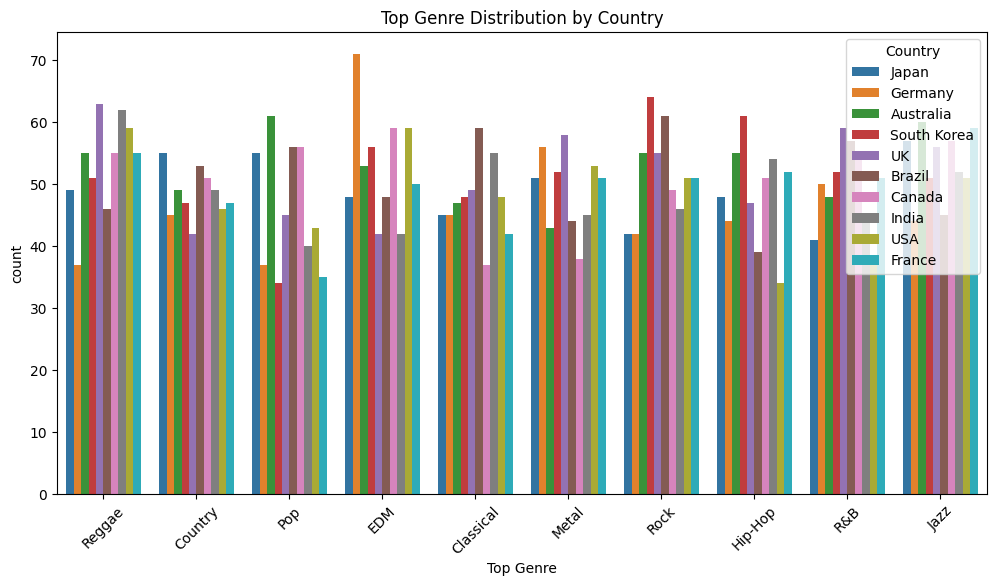

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Top Genre", hue="Country")

plt.title("Top Genre Distribution by Country")
plt.xticks(rotation=45)

plt.show()


>Top Genre distribution by Age

>Hue shift accounts for ages between the legend's marked colors. This data portrays younger groups listening to Reggae and EDM more than older groups. Those around the age of 24 or 56 tend to listen to Rock at an equal rate, while Metal is majorly listened to by those around the age of 32. The age groups in 40 and older tend to hold the highest listening rate of Country, with outliers existing between 32 and 40.

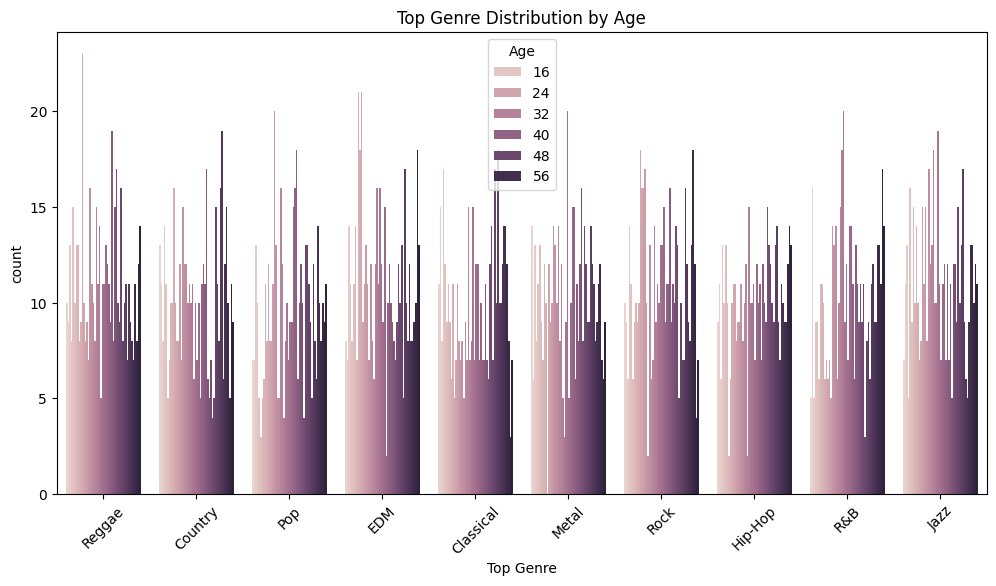

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Top Genre", hue="Age")

plt.title("Top Genre Distribution by Age")
plt.xticks(rotation=45)

plt.show()


>This line chart prioritizes the six most popular genres for easier visualization of which age holds a spike in the popularity of a genre.
>Preprocesses data by lessening the amount of genres looked at.
>Most Jazz listeners are in their late 20s and early 30s, matching the bar chart. However, one noticebale difference the line chart makes easier to see is that those around their mid 20s tend to listen to Rock slightly more frequently than those in their mid 50s.

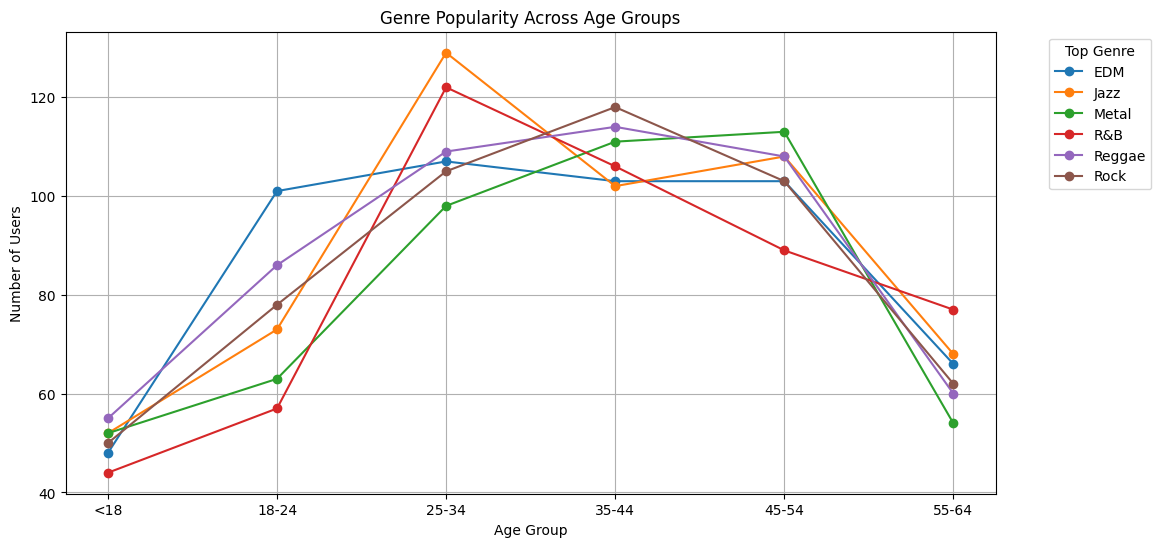

In [35]:
import pandas as pd
import matplotlib.pyplot as plt


# Load data
df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

top_genres = df["Top Genre"].value_counts().head(6).index
df = df[df["Top Genre"].isin(top_genres)]

# Bin ages into groups
bins = [0, 17, 24, 34, 44, 54, 64, 100]
labels = ["<18","18-24","25-34","35-44","45-54","55-64","65+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Count genre popularity by age group
genre_age = df.groupby(["Age Group", "Top Genre"]).size().reset_index(name="Count")

# Pivot for line chart
genre_age_pivot = genre_age.pivot(index="Age Group", columns="Top Genre", values="Count").fillna(0)

# Plot
plt.figure(figsize=(12,6))
for genre in genre_age_pivot.columns:
    plt.plot(genre_age_pivot.index, genre_age_pivot[genre], marker='o', label=genre)

plt.title("Genre Popularity Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.legend(title="Top Genre", bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.show()

# Data Transformation and Applying the Mining Technique

>Preprocessing was used to remove unnecessary data, such as USER ID.

>Transformation was accomplished by sorting numerical columns, such as stream and like counts per user, into bins.

,Minutes Streamed Per Day,Number of Songs Liked,Discover Weekly Engagement (%),Repeat Song Rate (%)
Behavior Cluster,,,,
0,371.485459,286.290828,51.365541,63.704728
1,447.118410,273.546240,49.700424,30.463405
2,287.375000,218.262579,50.850393,25.269929
3,134.282114,235.404065,49.118732,48.079472


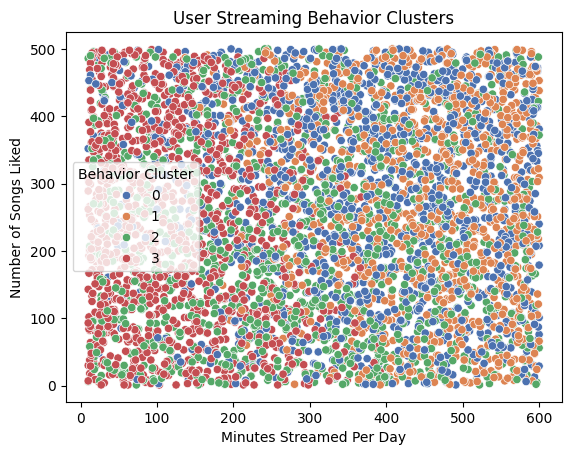

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

features = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Behavior Cluster"] = kmeans.fit_predict(scaled_features)

cluster_summary = df.groupby("Behavior Cluster")[[
    "Minutes Streamed Per Day",
    "Number of Songs Liked",
    "Discover Weekly Engagement (%)",
    "Repeat Song Rate (%)"
]].mean()

display(cluster_summary)

sns.scatterplot(
    data=df,
    x="Minutes Streamed Per Day",
    y="Number of Songs Liked",
    hue="Behavior Cluster",
    palette="deep"
)
plt.title("User Streaming Behavior Clusters")
plt.show()

In [9]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

# Remove USER ID
df = df.drop(columns=["User_ID"])

#Discretization
# Convert numerical columns into categories
df["Minutes Category"] = pd.qcut(
    df["Minutes Streamed Per Day"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

df["Songs Liked Category"] = pd.qcut(
    df["Number of Songs Liked"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

df["Repeat Rate Category"] = pd.qcut(
    df["Repeat Song Rate (%)"],
    q=4,
    labels=["Very Low","Low","Medium","High"]
)

df["Discover Weekly Category"] = pd.qcut(
    df["Discover Weekly Engagement (%)"],
    q=4,
    labels=["Very Low","Low","Medium","High"]
)

transactions = df[[
    "Country",
    "Top Genre",
    "Streaming Platform",
    "Minutes Category",
    "Discover Weekly Category",
    "Repeat Rate Category"
]]

# basket format
basket = pd.get_dummies(transactions)

# Find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

> Association rules through Apriori are applied as the data mining technique.

In [10]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules = rules[rules["lift"] > 1]
# Show top rules
print(rules.sort_values("lift", ascending=False).head(10))

# Make rules readable
rules_readable = rules.copy()

rules_readable["Antecedent"] = rules_readable["antecedents"].apply(lambda x: ', '.join(list(x)))
rules_readable["Consequent"] = rules_readable["consequents"].apply(lambda x: ', '.join(list(x)))

rules_readable = rules_readable[["Antecedent","Consequent","support","confidence","lift"]]

# Sort by strongest rules
rules_readable = rules_readable.sort_values(by="lift", ascending=False)

print(rules_readable.head(10))

                                           antecedents  \
63   frozenset({Streaming Platform_Tidal, Minutes C...   
148  frozenset({Subscription Type_Premium, Listenin...   
144  frozenset({Discover Weekly Category_Low, Subsc...   
90   frozenset({Subscription Type_Premium, Discover...   
61   frozenset({Subscription Type_Premium, Streamin...   
22                          frozenset({Top Genre_Pop})   
97   frozenset({Discover Weekly Category_Very Low, ...   
149  frozenset({Subscription Type_Premium, Listenin...   
154  frozenset({Subscription Type_Premium, Discover...   
110  frozenset({Listening Time (Morning/Afternoon/N...   

                                     consequents  antecedent support  \
63   frozenset({Songs Liked Category_Very High})              0.0796   
148  frozenset({Songs Liked Category_Very High})              0.0764   
144  frozenset({Songs Liked Category_Very High})              0.0706   
90   frozenset({Songs Liked Category_Very High})              0.1608   
6

>Minimum Support: 0.05 (5%) as the dataset has ~5000 rows, so this ensures that there a rule occurring in at least 250 users.
>Minimum Confidence: 0.6 (60%) as it ensures that the rule’s consequent occurs when the antecedent occurs, giving reliability.

>Frequent Item Sets Discovered:

| Feature | Label | Support |
| :--- | :--- | :--- |
| **Country** | USA | 0.45 |
| **Subscription Type** | Premium | 0.34 |
| **Streaming Platform** | Spotify | 0.31 |
| **Top Genre** | Pop | 0.29 |
| **Songs Liked** | Very High | 0.17 |
| **Repeat Rate** | Low | 0.13 |
| **Minutes Streamed** | Very High | 0.10 |



| Rule | Support | Confidence | Lift | Interpretation |
| :--- | :---: | :---: | :---: | :--- |
| **Songs Liked: Very High & Subscription: Premium** → Repeat Rate: Low | 0.05 | 0.38 | 1.12 | Premium users who like many songs usually repeat songs less. |
| **Repeat Rate: Low** → Songs Liked: Very High & Subscription: Premium | 0.05 | 0.15 | 1.12 | Users who repeat songs less are likely to own Premium. |
| **Minutes: Very High** → Country: UK | 0.05 | 0.11 | 1.11 | High streaming users are more likely to be in the UK. |
| **Country: UK** → Minutes: Very High | 0.05 | 0.50 | 1.11 | A slight tendency was observed between UK listeners and high streaming duration, but the lift value of 1.11 suggests this relationship is weak and only marginally above random co-occurrence.|
| **Streaming Platform: Spotify** → Discover Weekly: Low | 0.06 | 0.34 | 1.10 | Spotify users often have low engagement with Discover Weekly. |


>Interpretation:

>Behavioral patterns: High engagement users, who hold many liked songs or own premium, tend to not repeat songs. 

>Geography-platform interactions: Some countries stream more, and hold higher engagement with specfic platforms.

>It is surprising to see how certain countries, such as the UK stream more, but the most surprising how those with a Premium subscription do not repeat songs, even though it is one of the highlighted marketing points for Premium subscriptions across platforms. However, as an actionable interpretation, understanding streaming patterns can help curate playlists to retain user interaction by focusing on less repeats and more on featuring songs based on their liked songs.

# Preliminary Findings with Interpretation

Connecting to Discover Questions:

My discovery questions were given the feedback of being weak, so my comparisons focus on new questions. For example, "What associations exist between countries and genre preferences?"
In comparison to this first discovery question, what stood out from the EDA and association rules is there there is an uneven distribution of genres across the listed countries. For example, Germany listens to the EDM genre the most at 71 listeners, being the only nation to hold more than 60 listeners within this data sheet. This suggests that there is a geographic trend within Germany which makes EDM much more popular within the country.

My second discovery question has been rephrased to include trends within listening platforms, questioning "How do platform choice and user engagement correlate?" By focusing on this, the data has shown Spotify → Low Discover Weekly engagement (support = 5.68%, confidence = 34.3%, lift = 1.10) suggests that Spotify users are less likely to interact with automated playlists compared. Similarly, Amazon Music → High Songs Liked & Low Repeat Rate” (support = 5.3%, confidence = 30.7%, lift = 1.10) shows that Amazon Music users tend to explore more songs without repeating them. This may hold implications over how different recommendation algorithms affect user engagement, or imply that there are platform-specfic behaviors that may contribute to different spikes.

My third discovery question, "Do certain genres have a skewed age distribution within their region?" more properly connect with my findings from the line chart. This data shows that, though certain genres tend to be more popular within certain age groups, the data can be skewed by popularity within different regions. For example ages 18-24 hold hip-hop as their top genre, but it could be skewed by South Korea, which has Hip-Hop as one of its top genres, with listeners mainly being young adults.

Limitations and Surprises:

Limitations often came by mistakes made in M1, for example, changing Discovery Questions to better interpret the data, and expanding the focus on simply age and region, to also look at engagement and behavioral trends within streaming platforms. 
For example, Germany listening to EDM the most is not surprising, but seeing the UK with the highest minutes of streaming is interesting, as there is not a clear showcase of what could be causing this. 
As a result, my plan for M3 is to build off of geographical rules to apply to behavioral patterns. For example, looking into South Korea's hip-hop trend by cross-referencing the outliers in my data with historical and cultural factors across these regions. 